# Etapa 4 - Classificação com MLP (binária e multiclasse)

Duas MLPs Keras: binária (`Diabetes_binary`) e multiclasse (`Diabetes_012`).

Arquitetura baseline (justificada no relatório):
`Input → Dense(64, relu) → Dropout(0.3) → Dense(32, relu) → Dense(saída)`,
otimizador Adam (lr=1e-3), `EarlyStopping(patience=10, restore_best_weights=True)`,
`batch_size=256`, `class_weight='balanced'` (desbalanceamento).

Lógica reutilizável em `src/train.py`, `src/evaluation.py` e `src/classical_models.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import pandas as pd
from IPython.display import Image

import config
from src import evaluation as ev

config.set_seeds()

C:\Users\Tobias Viero\AppData\Local\Temp\ipykernel_28416\2673821045.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Treinar e avaliar (binária)

Treina a MLP, salva o modelo (`outputs/models/mlp_binary.keras`), avalia em validação e
uma vez no teste, gera as figuras e compara com modelos clássicos.

> Já há resultados salvos. Para **recomputar** (≈1 min em CPU), execute a célula abaixo.

In [2]:
# Recomputa as duas tarefas e salva classification_metrics.json:
# ev.run(tasks=("binary", "multiclass"))

metrics = json.load(open(config.METRICS_DIR / "classification_metrics.json", encoding="utf-8"))
list(metrics.keys())

['binary', 'multiclass']

## 2. Métricas no teste

Binária: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC.
Multiclasse: Accuracy, Precision/Recall/F1 macro.

In [3]:
for task in metrics:
    m = {k: v for k, v in metrics[task]["test"].items() if k != "confusion_matrix"}
    print(f"{task}: ", {k: round(v, 4) for k, v in m.items()})

binary:  {'accuracy': 0.7115, 'precision': 0.3004, 'recall': 0.8056, 'f1': 0.4377, 'roc_auc': 0.8262, 'pr_auc': 0.418}
multiclass:  {'accuracy': 0.6373, 'precision_macro': 0.4448, 'recall_macro': 0.521, 'f1_macro': 0.4235}


## 3. Curvas de aprendizado e matrizes de confusão (binária)

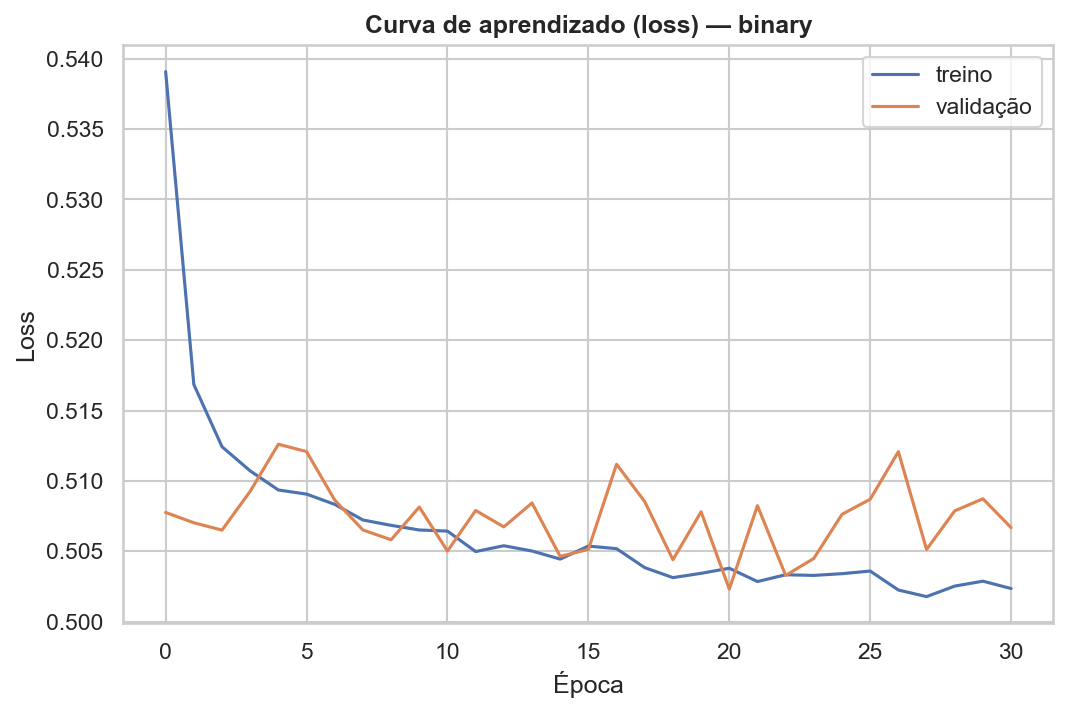

In [4]:
Image(str(config.FIGURES_DIR / "etapa4_loss_binary.png"))

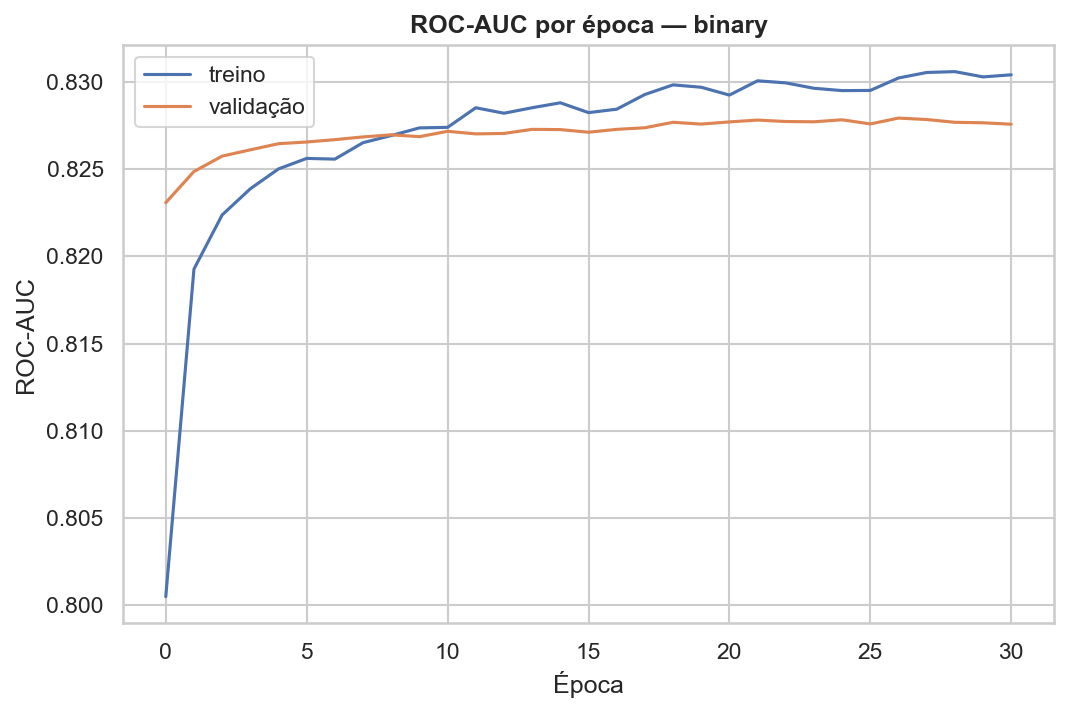

In [5]:
Image(str(config.FIGURES_DIR / "etapa4_metric_binary.png"))

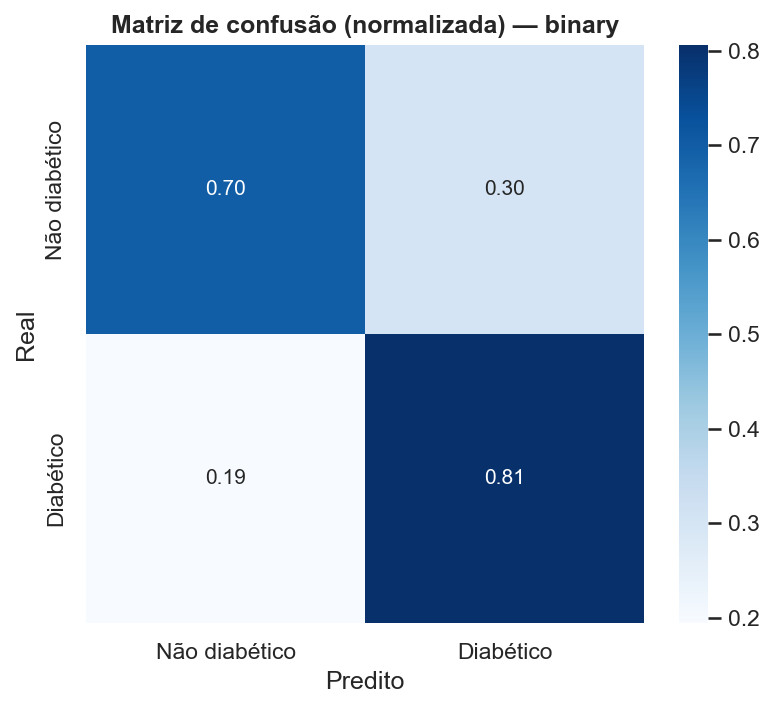

In [6]:
Image(str(config.FIGURES_DIR / "etapa4_confmat_binary.png"))

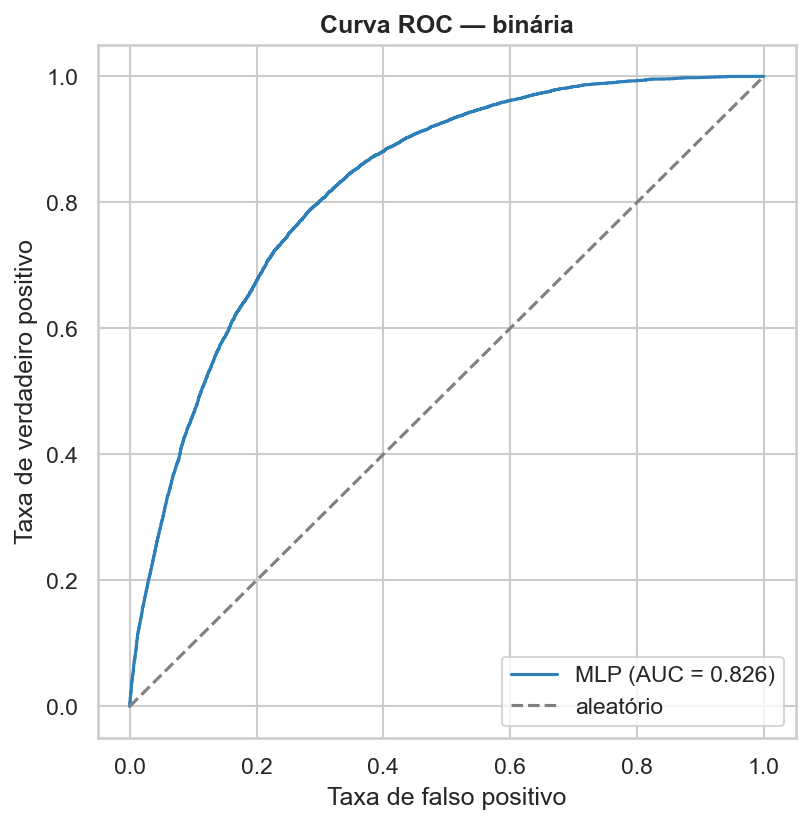

In [7]:
Image(str(config.FIGURES_DIR / "etapa4_roc_binaria.png"))

## 4. Multiclasse — curvas e matriz de confusão

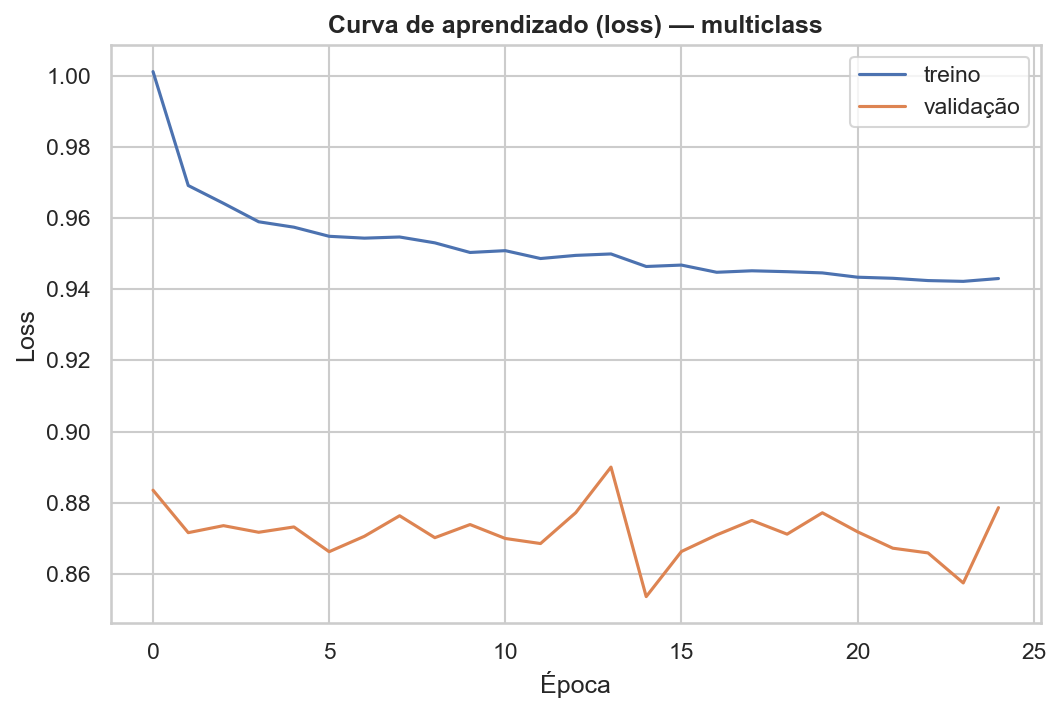

In [8]:
Image(str(config.FIGURES_DIR / "etapa4_loss_multiclass.png"))

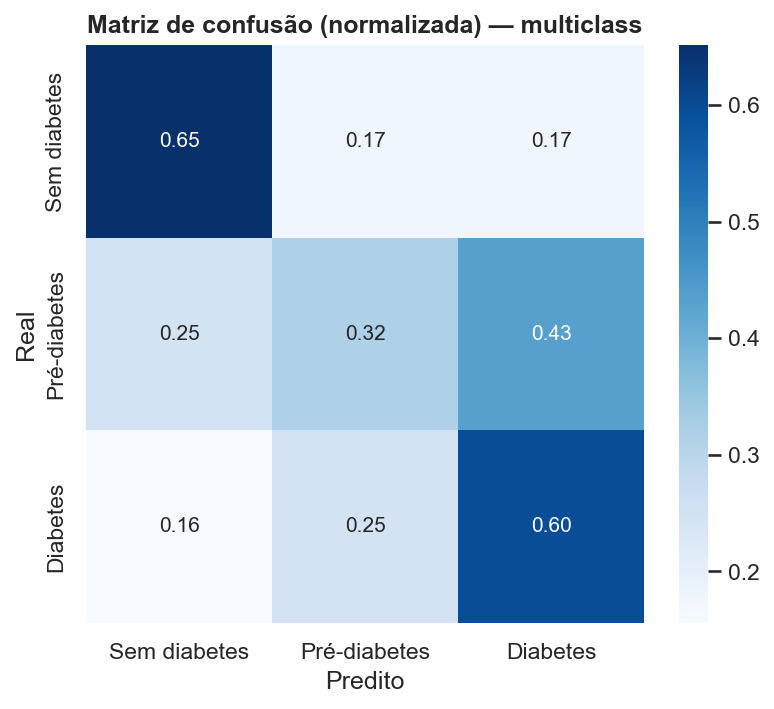

In [9]:
Image(str(config.FIGURES_DIR / "etapa4_confmat_multiclass.png"))

## 5. Extra - comparação com modelos clássicos

`LogisticRegression`, `RandomForest` e `XGBoost` nas mesmas features, comparando a
métrica principal e o custo computacional (tempo de treino e inferência).

In [10]:
for task in metrics:
    print(f"\n=== {task} ===")
    display(pd.read_csv(config.METRICS_DIR / f"classical_comparison_{task}.csv"))


=== binary ===


,modelo,roc_auc,pr_auc,f1,tempo_treino_s,tempo_inferencia_s
0,LogisticRegression,0.8197,0.3925,0.4411,0.18,0.0026
1,RandomForest,0.7962,0.3590,0.2326,2.18,0.2225
2,XGBoost,0.8230,0.4162,0.4421,0.70,0.0225



=== multiclass ===


,modelo,f1_macro,tempo_treino_s,tempo_inferencia_s
0,LogisticRegression,0.4260,0.96,0.0037
1,RandomForest,0.3832,2.25,0.2486
2,XGBoost,0.4001,1.27,0.0350
